1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

2. Load Data

In [25]:
df = pd.read_csv("../data/processed_data.csv")

target_column = "productivity_score"

X = df[
[
'study_hours_per_day',
'focus_score',
'sleep_hours',
'attendance_percentage',
'stress_level',
'phone_usage_hours',
'social_media_hours'
]]

y = df[target_column]

3. Load Model, Scaler & Polynomial Transformer

In [26]:
with open("../models/polynomial/model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/polynomial/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("../models/polynomial/poly.pkl", "rb") as f:
    poly = pickle.load(f)

4. Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Apply Polynomial Transformation

In [28]:
X_test_poly = poly.transform(X_test)

6. Scale Data

In [29]:
X_test_scaled = scaler.transform(X_test_poly)

7. Predictions

In [30]:
y_pred = model.predict(X_test_scaled)

8. Evaluation Metrics

In [31]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
a = accuracy_score(y_test.round(), y_pred.round())



print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Accuracy:", a)

MSE: 0.0005856248092108593
MAE: 0.006962189346543758
R2 Score: 0.9999977261122441
Accuracy: 0.9935


9. Graph 1: Actual vs Predicted

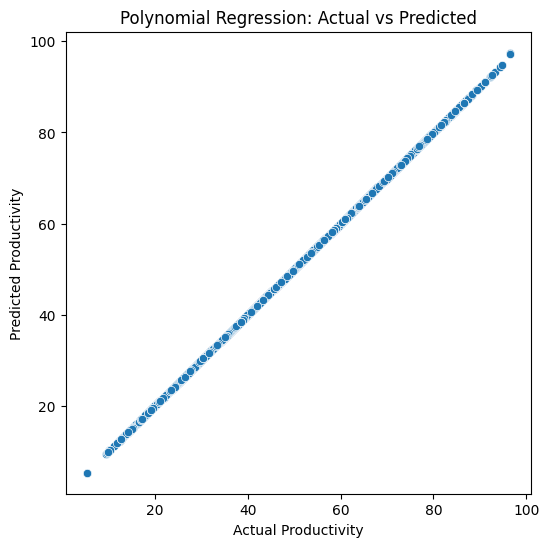

In [32]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

10. Residual Distribution

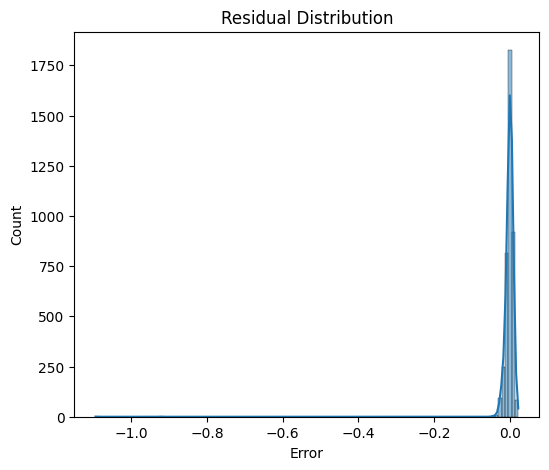

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

11. Residual vs Predicted

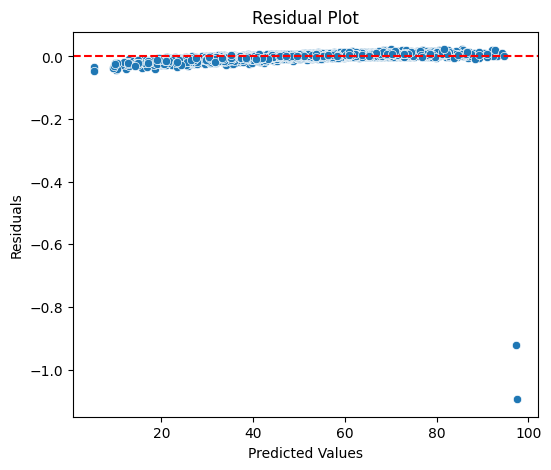

In [34]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()